In [5]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✓ Libraries loaded")

✓ Libraries loaded


# PostgreSQL Connection


In [ ]:
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@"
    f"{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as connection:
    connection.execute(text("SELECT 1"))

print("✓ PostgreSQL connection successful")

✓ PostgreSQL connection successful


# Build Order-Level ML Dataset

In [9]:
ml_query = """
WITH order_base AS (

    SELECT
        o.order_id,
        o.customer_id,
        o.order_status,
        o.purchase_date,
        o.purchase_year,
        o.purchase_month,
        o.purchase_quarter,
        o.purchase_weekday,
        o.purchase_hour,
        o.is_weekend,
        o.is_holiday,
        o.holiday,
        o.delivery_delay_days,
        o.delivery_status

    FROM staging.stg_orders o
),

item_agg AS (

    SELECT
        oi.order_id,

        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,

        COUNT(*) AS items_per_order,

        COUNT(DISTINCT oi.seller_id) AS seller_count,
        COUNT(DISTINCT oi.product_id) AS product_count

    FROM staging.stg_order_items oi

    GROUP BY oi.order_id
),

payment_agg AS (

    SELECT
        op.order_id,

        SUM(op.payment_value) AS total_payment_value,

        MAX(op.payment_installments) AS max_payment_installments,

        STRING_AGG(
            DISTINCT op.payment_type,
            ', '
            ORDER BY op.payment_type
        ) AS payment_type

    FROM staging.stg_order_payments op

    GROUP BY op.order_id
),

customer_dim AS (

    SELECT
        customer_id,
        customer_state

    FROM chrily.dim_customer
),

seller_info AS (

    SELECT
        oi.order_id,

        MODE() WITHIN GROUP (
            ORDER BY s.seller_state
        ) AS seller_state

    FROM staging.stg_order_items oi

    LEFT JOIN chrily.dim_seller s
        ON oi.seller_id = s.seller_id

    GROUP BY oi.order_id
),

product_info AS (

    SELECT
        oi.order_id,

        MODE() WITHIN GROUP (
            ORDER BY p.product_category_name
        ) AS product_category_name

    FROM staging.stg_order_items oi

    LEFT JOIN chrily.dim_product p
        ON oi.product_id = p.product_id

    GROUP BY oi.order_id
)

SELECT

    o.order_id,

    -- Target source
    o.delivery_delay_days,
    o.delivery_status,

    -- Order timing
    o.purchase_year,
    o.purchase_month,
    o.purchase_quarter,
    o.purchase_weekday,
    o.purchase_hour,
    o.is_weekend,
    o.is_holiday,
    o.holiday,

    -- Order characteristics
    i.total_price,
    i.total_freight,
    i.items_per_order,
    i.seller_count,
    i.product_count,

    -- Payment characteristics
    p.total_payment_value,
    p.max_payment_installments,
    p.payment_type,

    -- Geography
    c.customer_state,
    s.seller_state,

    -- Product
    pr.product_category_name

FROM order_base o

LEFT JOIN item_agg i
    ON o.order_id = i.order_id

LEFT JOIN payment_agg p
    ON o.order_id = p.order_id

LEFT JOIN customer_dim c
    ON o.customer_id = c.customer_id

LEFT JOIN seller_info s
    ON o.order_id = s.order_id

LEFT JOIN product_info pr
    ON o.order_id = pr.order_id

WHERE
    o.delivery_delay_days IS NOT NULL
;
"""

ml_df = pd.read_sql(ml_query, engine)

print("✓ ML dataset created")
print(f"Rows: {len(ml_df):,}")
print(f"Columns: {ml_df.shape[1]}")

✓ ML dataset created
Rows: 96,476
Columns: 22


In [10]:
display(ml_df.head())

print("\nShape:")
print(ml_df.shape)

print("\nData types:")
display(ml_df.dtypes)

print("\nMissing values:")
display(
    ml_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

,order_id,delivery_delay_days,delivery_status,purchase_year,purchase_month,purchase_quarter,purchase_weekday,purchase_hour,is_weekend,is_holiday,holiday,total_price,total_freight,items_per_order,seller_count,product_count,total_payment_value,max_payment_installments,payment_type,customer_state,seller_state,product_category_name
0,00018f77f2f0320c557190d7a144bdd3,-3.0,Early,2025,4,2,Saturday,10,True,False,NaN,439.02,36.47,1,1,1,475.49,3.0,Bank Card,Casablanca-Settat,Casablanca-Settat,Pet Supplies
1,000229ec398224ef6ca0657da4fc703e,-14.0,Early,2026,1,1,Wednesday,14,False,False,NaN,364.17,32.70,1,1,1,396.87,5.0,Bank Card,Tanger-Tétouan-Al Hoceïma,Tanger-Tétouan-Al Hoceïma,Home Decor
2,00024acbcdf0a6daa1e931b038114c75,-6.0,Early,2026,8,3,Saturday,10,True,False,NaN,23.77,23.41,1,1,1,47.18,2.0,Bank Card,Casablanca-Settat,Casablanca-Settat,Beauty & Cosmetics
3,00042b26cf59d7ce69dfabb4e55b4fd9,-16.0,Early,2025,2,1,Tuesday,13,False,False,NaN,365.82,33.20,1,1,1,399.01,3.0,Bank Card,Casablanca-Settat,Fès-Meknès,ferramentas_jardim
4,000576fe39319847cbb9d288c5617fa6,-16.0,Early,2026,7,3,Saturday,12,True,False,NaN,1482.30,129.47,1,1,1,1611.77,10.0,Bank Card,Casablanca-Settat,Casablanca-Settat,ferramentas_jardim



Shape:
(96476, 22)

Data types:


order_id                        str
delivery_delay_days         float64
delivery_status                 str
purchase_year                 int64
purchase_month                int64
purchase_quarter              int64
purchase_weekday                str
purchase_hour                 int64
is_weekend                     bool
is_holiday                     bool
holiday                         str
total_price                 float64
total_freight               float64
items_per_order               int64
seller_count                  int64
product_count                 int64
total_payment_value         float64
max_payment_installments    float64
payment_type                    str
customer_state                  str
seller_state                    str
product_category_name           str
dtype: object


Missing values:


,missing_values
holiday,92104
payment_type,3
max_payment_installments,3
total_payment_value,3
order_id,0
delivery_delay_days,0
purchase_quarter,0
purchase_month,0
purchase_year,0
delivery_status,0


In [11]:
total_rows = len(ml_df)
unique_orders = ml_df["order_id"].nunique()

print(f"Total rows:      {total_rows:,}")
print(f"Unique orders:   {unique_orders:,}")

if total_rows == unique_orders:
    print("✓ Correct grain: 1 row per order")
else:
    print("⚠ Duplicate order_id values detected")

Total rows:      96,476
Unique orders:   96,476
✓ Correct grain: 1 row per order


In [12]:
ml_df["late_delivery"] = (
    ml_df["delivery_delay_days"] > 0
).astype(int)

print("✓ Target created")

display(
    ml_df["late_delivery"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "On-Time / Early",
        1: "Late"
    })
    .to_frame("orders")
)

✓ Target created


,orders
late_delivery,
On-Time / Early,89941
Late,6535


In [13]:
target_counts = ml_df["late_delivery"].value_counts()

target_pct = (
    ml_df["late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "orders": target_counts,
    "percentage": target_pct
})

target_summary.index = [
    "On-Time / Early" if x == 0 else "Late"
    for x in target_summary.index
]

display(target_summary)

,orders,percentage
On-Time / Early,89941,93.23
Late,6535,6.77


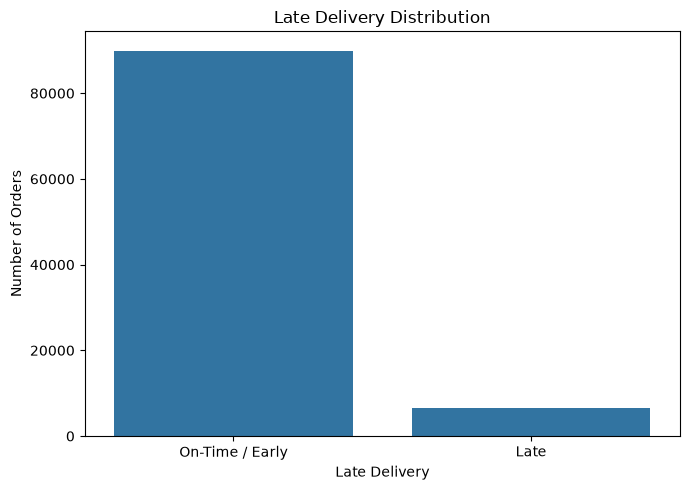

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=ml_df,
    x="late_delivery"
)

plt.title("Late Delivery Distribution")
plt.xlabel("Late Delivery")
plt.ylabel("Number of Orders")

plt.xticks(
    [0, 1],
    ["On-Time / Early", "Late"]
)

plt.tight_layout()
plt.show()

# Leakage Prevention

In [15]:
leakage_columns = [
    "order_id",
    "delivery_delay_days",
    "delivery_status"
]

ml_model_df = ml_df.drop(
    columns=leakage_columns
).copy()

print("✓ Leakage columns removed")
print(leakage_columns)

✓ Leakage columns removed
['order_id', 'delivery_delay_days', 'delivery_status']


# Features and Target

In [16]:
X = ml_model_df.drop(
    columns=["late_delivery"]
)

y = ml_model_df["late_delivery"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nFeature columns:")
for col in X.columns:
    print("-", col)

Features: (96476, 19)
Target: (96476,)

Feature columns:
- purchase_year
- purchase_month
- purchase_quarter
- purchase_weekday
- purchase_hour
- is_weekend
- is_holiday
- holiday
- total_price
- total_freight
- items_per_order
- seller_count
- product_count
- total_payment_value
- max_payment_installments
- payment_type
- customer_state
- seller_state
- product_category_name


# Remove Low-Value Feature

In [17]:
if "holiday" in X.columns:
    X = X.drop(columns=["holiday"])

print("✓ Holiday text column removed")
print("Remaining features:", X.shape[1])

✓ Holiday text column removed
Remaining features: 18


# Feature Types

In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print("Numeric features:")
for col in numeric_features:
    print(" -", col)

print("\nCategorical features:")
for col in categorical_features:
    print(" -", col)

Numeric features:
 - purchase_year
 - purchase_month
 - purchase_quarter
 - purchase_hour
 - total_price
 - total_freight
 - items_per_order
 - seller_count
 - product_count
 - total_payment_value
 - max_payment_installments

Categorical features:
 - purchase_weekday
 - is_weekend
 - is_holiday
 - payment_type
 - customer_state
 - seller_state
 - product_category_name


# Class Balance


In [19]:
class_balance = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    class_balance.to_frame("percentage")
)

,percentage
late_delivery,
0,93.23
1,6.77


# Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

Training set: (77180, 18)
Testing set:  (19296, 18)

Training target distribution:


,percentage
late_delivery,
0,93.23
1,6.77



Testing target distribution:


,percentage
late_delivery,
0,93.23
1,6.77


# Preprocessing Pipeline


In [21]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("✓ Preprocessing pipeline created")

✓ Preprocessing pipeline created


# Logistic Regression


In [22]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("✓ Logistic Regression pipeline ready")

✓ Logistic Regression pipeline ready


# Random Forest


In [23]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("✓ Random Forest pipeline ready")

✓ Random Forest pipeline ready


# Train Logistic Regression


In [24]:
print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("✓ Logistic Regression trained")

Training Logistic Regression...
✓ Logistic Regression trained


# Train Random Forest


In [25]:
print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("✓ Random Forest trained")

Training Random Forest...
✓ Random Forest trained


# Predictions


In [26]:
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")

✓ Predictions generated


# Model Evaluation Function


In [27]:
def evaluate_model(name, y_true, y_pred, y_prob):

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    return results

# Model Comparison


In [28]:
results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
])

results = results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.800,0.185,0.572,0.279,0.763
1,Logistic Regression,0.641,0.109,0.602,0.185,0.667


# Logistic Regression Classification Report


In [29]:
print("Logistic Regression")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "On-Time / Early",
            "Late"
        ],
        zero_division=0
    )
)

Logistic Regression
                 precision    recall  f1-score   support

On-Time / Early       0.96      0.64      0.77     17989
           Late       0.11      0.60      0.19      1307

       accuracy                           0.64     19296
      macro avg       0.53      0.62      0.48     19296
   weighted avg       0.90      0.64      0.73     19296



# Random Forest Classification Report


In [30]:
print("Random Forest")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "On-Time / Early",
            "Late"
        ],
        zero_division=0
    )
)

Random Forest
                 precision    recall  f1-score   support

On-Time / Early       0.96      0.82      0.88     17989
           Late       0.18      0.57      0.28      1307

       accuracy                           0.80     19296
      macro avg       0.57      0.69      0.58     19296
   weighted avg       0.91      0.80      0.84     19296



# Logistic Regression Confusion Matrix


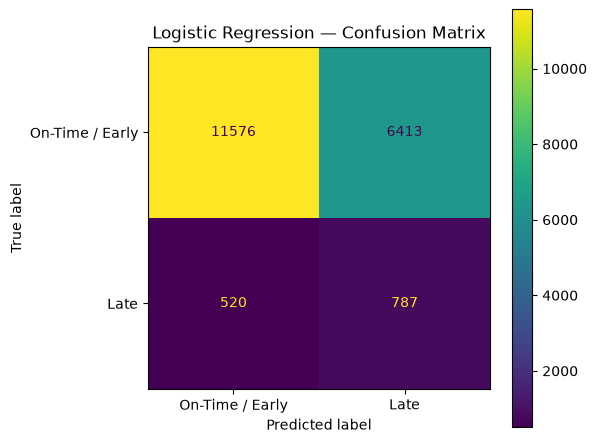

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=[
        "On-Time / Early",
        "Late"
    ],
    ax=ax
)

ax.set_title("Logistic Regression — Confusion Matrix")

plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix


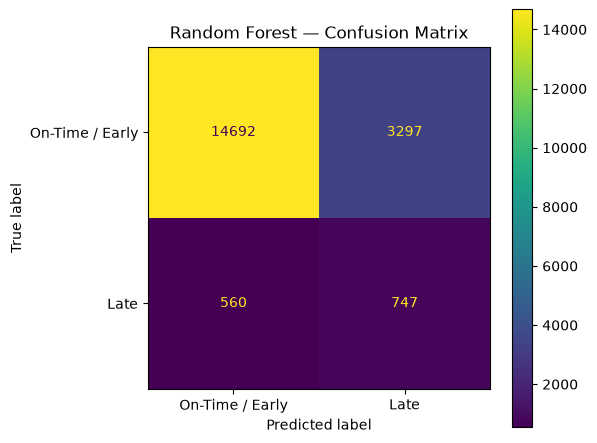

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=[
        "On-Time / Early",
        "Late"
    ],
    ax=ax
)

ax.set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.show()

# ROC Curve Comparison


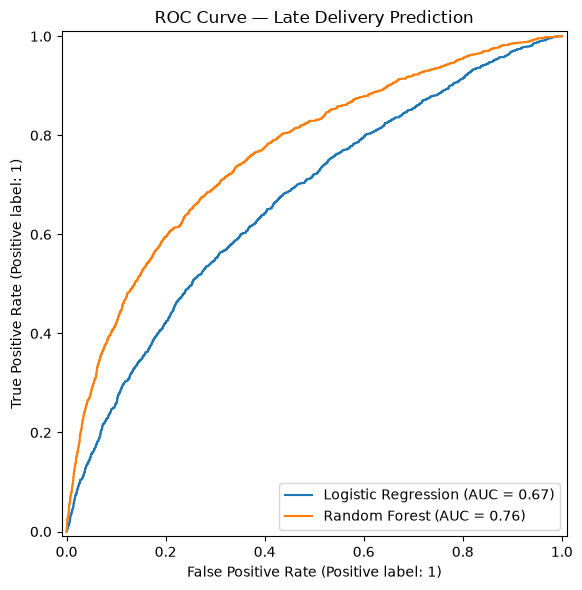

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_prob,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=ax
)

ax.set_title("ROC Curve — Late Delivery Prediction")

plt.tight_layout()
plt.show()

# Random Forest Feature Importance


In [34]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(importance_df)

,feature,importance
0,num__purchase_month,0.202923
1,num__purchase_quarter,0.124545
2,num__total_freight,0.092271
3,num__total_payment_value,0.055446
4,cat__customer_state_Casablanca-Settat,0.053153
5,num__total_price,0.052276
6,num__purchase_year,0.048634
7,cat__customer_state_Rabat-Salé-Kénitra,0.041344
8,num__purchase_hour,0.033836
9,cat__customer_state_Oriental,0.021223


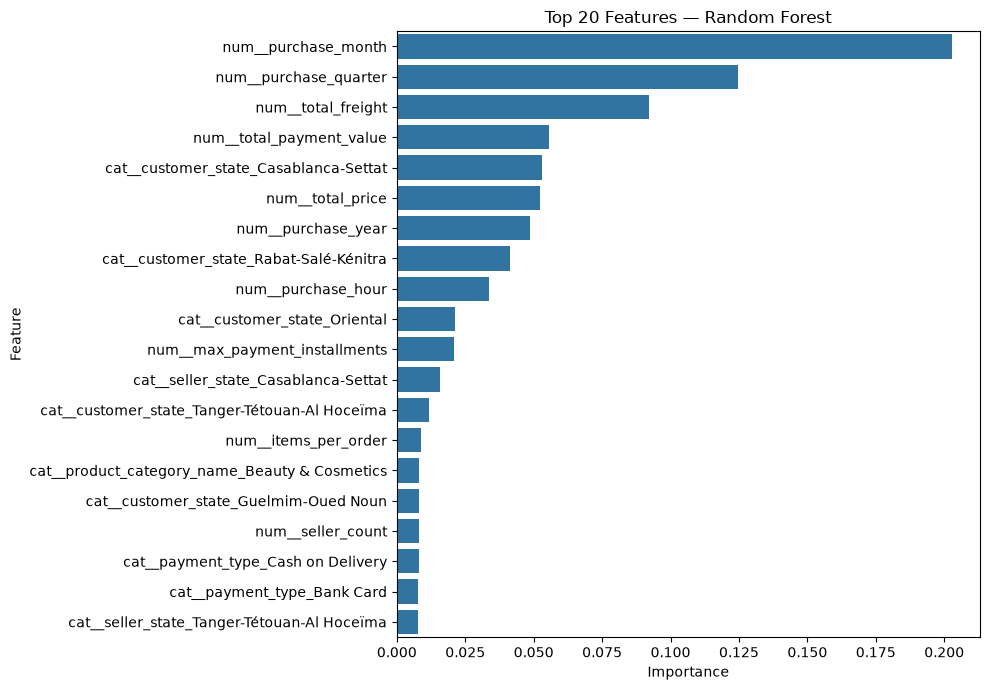

In [35]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Top 20 Features — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Select Best Model


In [36]:
best_model_name = results.loc[
    0,
    "Model"
]

if best_model_name == "Random Forest":
    best_model = random_forest_model
else:
    best_model = logistic_model

print(f"✓ Best model based on ROC-AUC: {best_model_name}")

✓ Best model based on ROC-AUC: Random Forest


# Save Best Model


In [37]:
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "late_delivery_random_forest.joblib"
)

joblib.dump(
    best_model,
    model_path
)

print(f"✓ Model saved to: {model_path}")

✓ Model saved to: ../models\late_delivery_random_forest.joblib


# Final Prediction Check


In [38]:
sample = X_test.head(10)

sample_predictions = best_model.predict(sample)
sample_probabilities = best_model.predict_proba(sample)[:, 1]

prediction_check = pd.DataFrame({
    "actual": y_test.head(10).values,
    "predicted": sample_predictions,
    "late_probability": sample_probabilities.round(3)
})

display(prediction_check)

,actual,predicted,late_probability
0,0,0,0.388
1,0,0,0.309
2,1,1,0.734
3,0,0,0.376
4,0,0,0.343
5,0,0,0.340
6,0,1,0.597
7,0,0,0.371
8,0,1,0.539
9,0,0,0.340


# Final ML Summary


In [39]:
best_results = results.iloc[0]

print("=" * 60)
print("CHRiLy — LATE DELIVERY PREDICTION")
print("=" * 60)

print(f"Best Model:       {best_results['Model']}")
print(f"Accuracy:         {best_results['Accuracy']:.3f}")
print(f"Precision:        {best_results['Precision']:.3f}")
print(f"Recall:           {best_results['Recall']:.3f}")
print(f"F1 Score:         {best_results['F1 Score']:.3f}")
print(f"ROC-AUC:          {best_results['ROC-AUC']:.3f}")

print("=" * 60)

CHRiLy — LATE DELIVERY PREDICTION
Best Model:       Random Forest
Accuracy:         0.800
Precision:        0.185
Recall:           0.572
F1 Score:         0.279
ROC-AUC:          0.763
